In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [93]:
df = pd.read_csv("indian_AG.csv")

In [94]:
print("Shape of dataset:", df.shape)
print("\nColumns:\n", df.columns)

print("\nInfo:")
print(df.info())

print("\nFirst 5 rows:")
print(df.head())


Shape of dataset: (232, 569)

Columns:
 Index(['dataset_id', 'label', 'Unnamed: 0', 'TMEM174', 'SPRR2F', 'PGA3',
       'FEZF2', 'CTXN3', 'ACSM2A', 'OR2T34',
       ...
       'TP53', 'CCND1', 'CDH1', 'PIK3CA', 'EGFR', 'VEGFA', 'CDH3', 'FOXC1',
       'CENPF', 'TYMS'],
      dtype='str', length=569)

Info:
<class 'pandas.DataFrame'>
RangeIndex: 232 entries, 0 to 231
Columns: 569 entries, dataset_id to TYMS
dtypes: float64(567), int64(1), str(1)
memory usage: 1.0 MB
None

First 5 rows:
  dataset_id  label  Unnamed: 0   TMEM174    SPRR2F      PGA3     FEZF2  \
0     Indian      1         0.0 -0.721355 -0.216780 -1.008839 -1.323460   
1     Indian      1         0.0 -0.267358 -0.220128 -0.273834  0.096592   
2     Indian      1         0.0  0.385866 -0.216528 -0.017420  0.045746   
3     Indian      1         0.0 -0.695469 -0.217764 -0.686974 -0.392542   
4     Indian      1         0.0 -0.801484 -0.215644 -0.537422 -0.994529   

   CTXN3  ACSM2A  OR2T34  ...      TP53     CCND1      CDH1

In [95]:
df = df.drop(columns=["Unnamed: 0", "dataset_id"], errors='ignore')


In [96]:
print("\nMissing Values:\n", df.isnull().sum().sum())



Missing Values:
 0


In [97]:
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
            label     TMEM174      SPRR2F        PGA3       FEZF2  CTXN3  \
count  232.000000  232.000000  232.000000  232.000000  232.000000  232.0   
mean     0.500000    0.224802   -0.120913    0.668493    0.247705    0.0   
std      0.501081    0.892509    0.610774    1.272908    0.786908    0.0   
min      0.000000   -1.442904   -0.227851   -1.178457   -1.639890    0.0   
25%      0.000000   -0.483885   -0.219008   -0.573948   -0.331119    0.0   
50%      0.500000    0.082822   -0.217026    0.653134    0.576562    0.0   
75%      1.000000    0.965933   -0.211349    1.315887    0.809338    0.0   
max      1.000000    2.929913    5.520921    3.185675    2.189074    0.0   

       ACSM2A  OR2T34      DNAJB8  SLC2A2  ...        TP53       CCND1  \
count   232.0   232.0  232.000000   232.0  ...  232.000000  232.000000   
mean      0.0     0.0   -0.081675     0.0  ...   -0.274740   -0.186895   
std       0.0     0.0    0.758450     0.0  ...    0.872730    0.745979 

In [98]:
print("\nLabel Distribution:")
print(df['label'].value_counts())



Label Distribution:
label
1    116
0    116
Name: count, dtype: int64


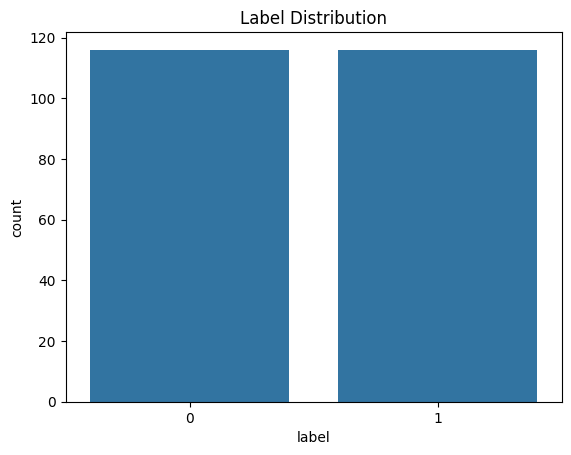

In [99]:
sns.countplot(x='label', data=df)
plt.title("Label Distribution")
plt.show()

In [100]:
corr = df.corr()

top_features = corr['label'].abs().sort_values(ascending=False)[1:21]

print("\nTop 20 Important Features:\n", top_features)



Top 20 Important Features:
 ABCA8       0.971543
SRPX        0.961619
GSN         0.941522
F10         0.938525
SCARA5      0.927345
EDNRB       0.924621
SCN4B       0.922604
SLC25A34    0.918078
CD300LG     0.914885
CAV1        0.911687
GPC3        0.911387
EGR1        0.910527
CA4         0.907869
RHOJ        0.907699
GPIHBP1     0.907172
LEPR        0.901766
LDB2        0.892755
CAPN11      0.883929
LMOD1       0.883494
MAMDC2      0.880465
Name: label, dtype: float64


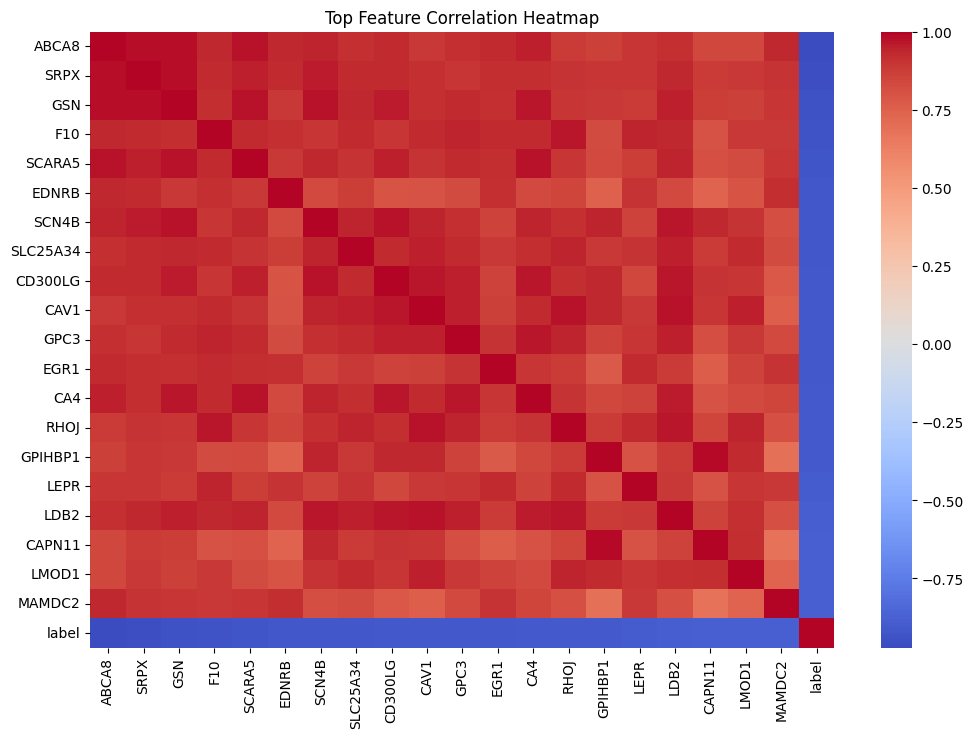

In [101]:
top_cols = top_features.index.tolist() + ['label']
plt.figure(figsize=(12,8))
sns.heatmap(df[top_cols].corr(), annot=False, cmap='coolwarm')
plt.title("Top Feature Correlation Heatmap")
plt.show()

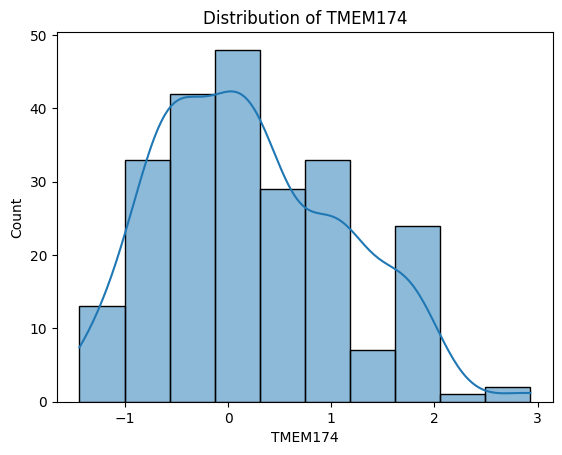

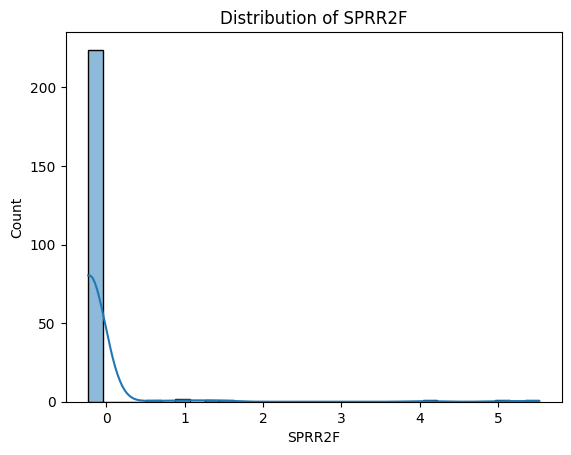

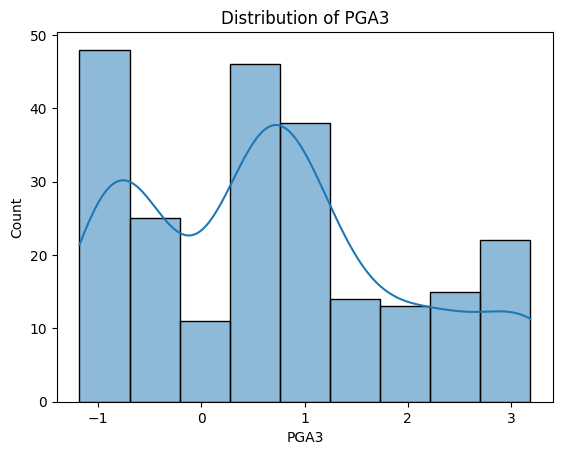

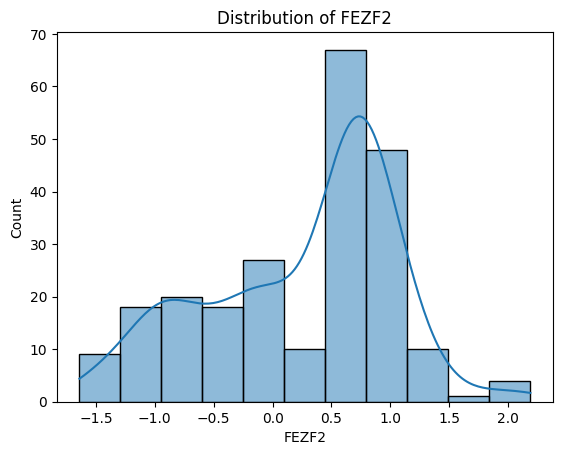

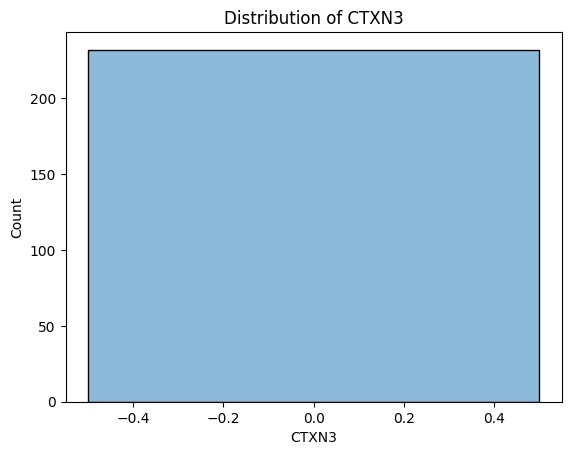

In [102]:
sample_features = df.columns[1:6]

for col in sample_features:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()


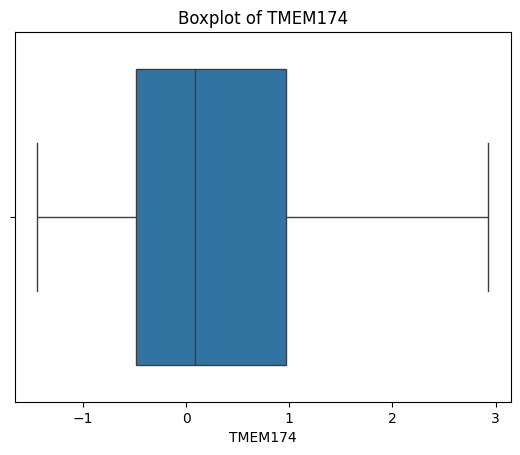

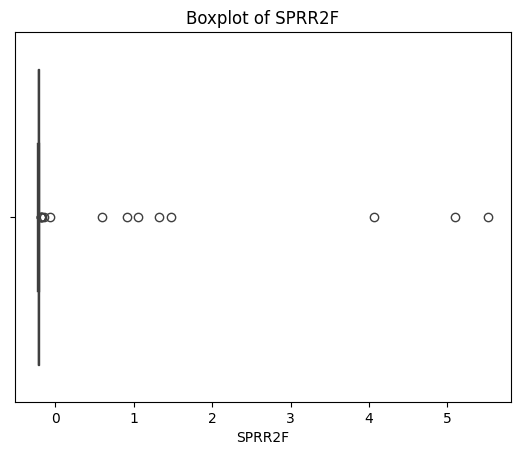

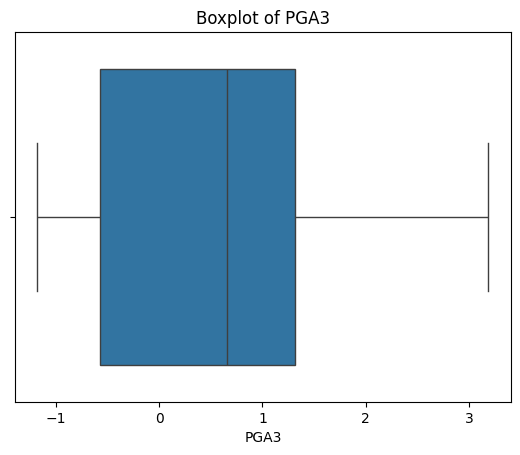

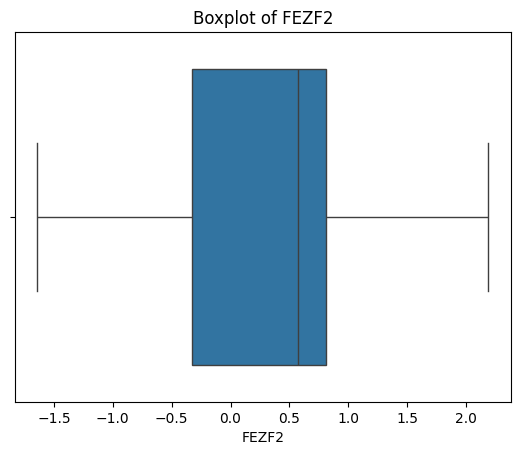

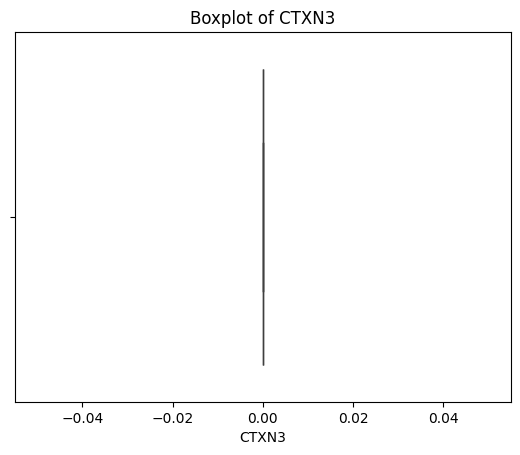

In [103]:
for col in sample_features:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

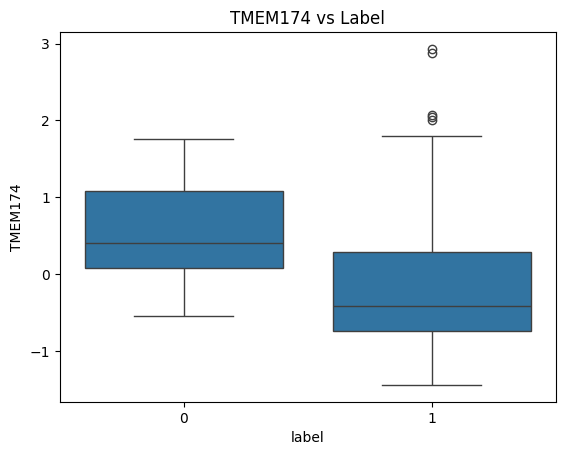

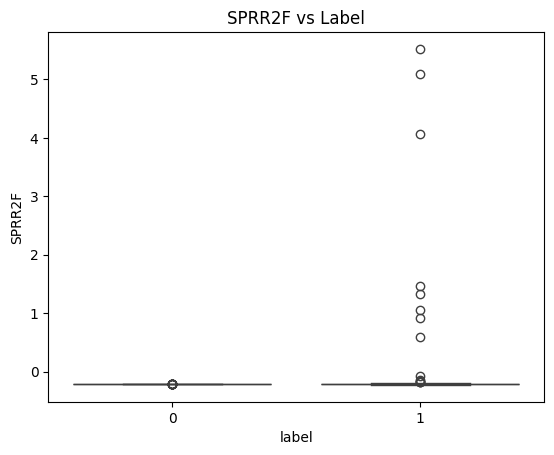

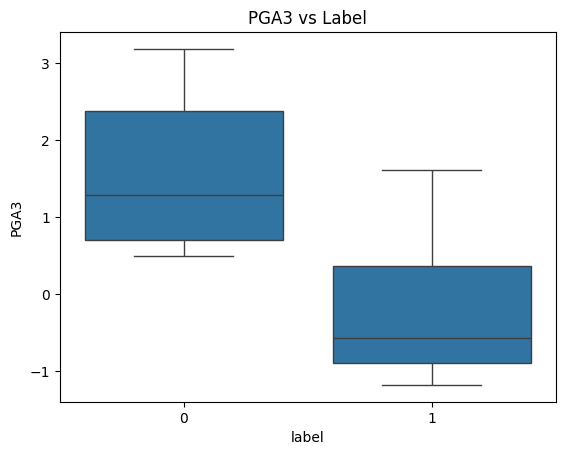

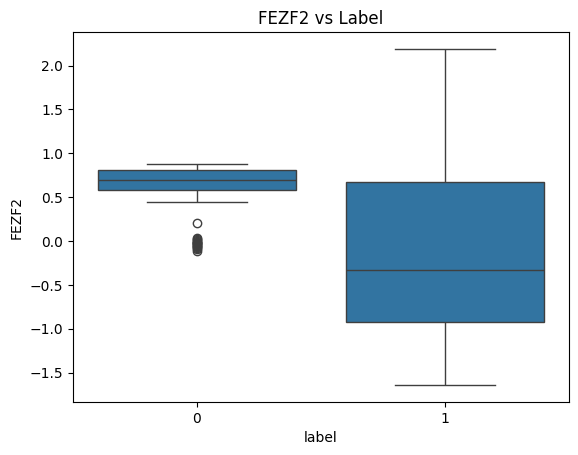

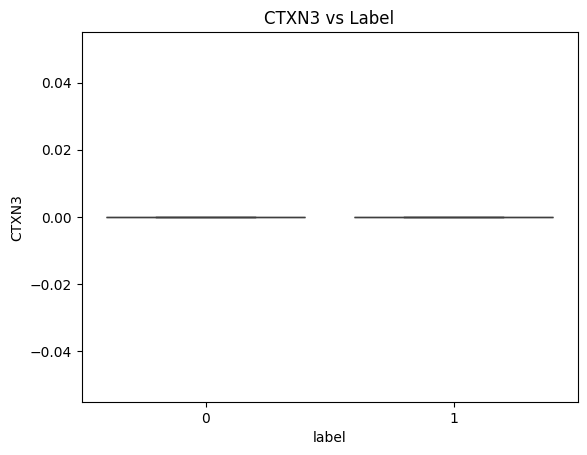

In [104]:
for col in sample_features:
    plt.figure()
    sns.boxplot(x='label', y=col, data=df)
    plt.title(f"{col} vs Label")
    plt.show()

In [105]:
top_50 = corr['label'].abs().sort_values(ascending=False)[1:51].index

df_reduced = df[top_50.tolist() + ['label']]

print("\nReduced dataset shape:", df_reduced.shape)


Reduced dataset shape: (232, 51)
